# Datasets Preparation

In [1]:
verbose = False
%run ./2_0_datasets_preparation.ipynb

START DATASETS PREPARATION
verbose is False
>> imports
>> load trajectories
>> load bathymetry
>> load SWAN waterlevel
>> load wind
>> preprocessing bathymetry
resolution original dataset x~20.196657m and y~20.324707m
resolution downscaled x~100.982443m and y~101.623535m
>> preprocessing wind
>> defining misc shared methods
DONE DATASETS PREPARATION


## Render 50x50m maps around transitions

https://www.openstreetmap.org/#map=19/52.962635/4.777577


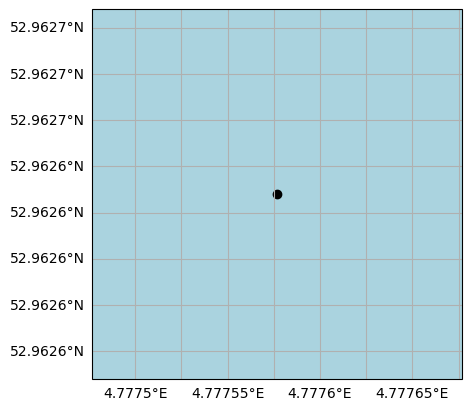

In [2]:
#TESTING/DEBUGGING map should show the Veerhaven at Den Helder

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
lon,lat = 4.77757662,52.96263495 #deg
dl = 0.0001 #deg
zoom = 19 #max19

print("https://www.openstreetmap.org/#map=19/%f/%f"%(lat,lon))

extent=[[lon-dl,lon+dl],[lat-dl,lat+dl]]
fig = plt.figure()
tiles = cimgt.OSM()
ax = plt.axes(projection=ccrs.PlateCarree())#tiles.crs)
ax.set_xlim(extent[0])
ax.set_ylim(extent[1])
ax.gridlines(draw_labels=['left','bottom'])
ax.add_image(tiles, zoom)
ax.scatter(lon, lat, c='black')
plt.show()

Loading OSM tiles via cartopy.io.img_tiles did not work on March 20th, printing links below
https://www.openstreetmap.org/#map=19/53.101710/4.898398 trayectory 0 event G lon 4.898398 lat 53.101710 timestep 668
https://www.openstreetmap.org/#map=19/53.101510/4.898398 trayectory 0 event W lon 4.898398 lat 53.101510 timestep 686
https://www.openstreetmap.org/#map=19/53.079380/4.897389 trayectory 0 event G lon 4.897389 lat 53.079380 timestep 933
https://www.openstreetmap.org/#map=19/53.079860/4.897454 trayectory 0 event W lon 4.897454 lat 53.079860 timestep 1505
https://www.openstreetmap.org/#map=19/53.292300/5.063426 trayectory 1 event G lon 5.063426 lat 53.292300 timestep 1157
https://www.openstreetmap.org/#map=19/53.292300/5.063426 trayectory 1 event W lon 5.063426 lat 53.292300 timestep 1209
https://www.openstreetmap.org/#map=19/53.294080/5.064069 trayectory 1 event G lon 5.064069 lat 53.294080 timestep 1215
https://www.openstreetmap.org/#map=19/53.294080/5.064134 trayectory 1 event W 

KeyboardInterrupt: 

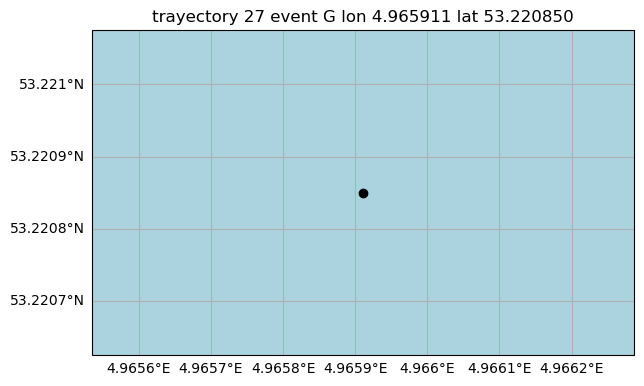

In [ ]:
area_m = 50 # width and height of the plotted maps
figsize_side = 7
verbose = False

import utils
import matplotlib.pyplot as plt
import numpy as np

print("Loading OSM tiles via cartopy.io.img_tiles did not work on March 20th, this script prints out links to the map locations instead and this section will be revised later")
for it in range(len(trajectories)):
  inds = (trajectories[it].label.values==-1.0)+(trajectories[it].label.values==1.0)
  lons, lats, labels = trajectories[it].lon.values[inds], trajectories[it].lat.values[inds], trajectories[it].label.values[inds]
  for i in range(len(labels)):
    its = np.argwhere(inds)[i]
    its = its if isinstance(its, int) else its[0]
    lon, lat, label = lons[i], lats[i], 'G' if labels[i]==1.0 else 'W' # = trajectories[i].lon.values[inds], trajectories[i].lat.values[inds]
    title = "trayectory %d event %s lon %.6f lat %.6f timestep %d" % (it, label, lon, lat, its)
    print("https://www.openstreetmap.org/#map=19/%f/%f %s"%(lat,lon,title))

for it in range(len(trajectories)):
  inds = (trajectories[it].label.values==-1.0)+(trajectories[it].label.values==1.0)
  lons, lats, labels = trajectories[it].lon.values[inds], trajectories[it].lat.values[inds], trajectories[it].label.values[inds]
  for i in range(len(labels)):
    its = np.argwhere(inds)[i]
    its = its if isinstance(its, int) else its[0]
    lon, lat, label = lons[i], lats[i], 'G' if labels[i]==1.0 else 'W' # = trajectories[i].lon.values[inds], trajectories[i].lat.values[inds]
    #print("https://www.openstreetmap.org/#map=19/%f/%f"%(lat,lon))
    title = "trayectory %d event %s lon %.6f lat %.6f" % (it, label, lon, lat)
    dlat, dlon = area_m/(111.*1000), area_m/(111.*1000)/np.cos(np.deg2rad(lat))
    #print("dx%.1fm dy%.1fm" % (utils.distance_coords_to_meters(lon-dlon/2,lat,lon+dlon/2,lat),utils.distance_coords_to_meters(lon,lat-dlat/2.,lon,lat+dlat/2.)))
    extent_wsc=[[lon-dlon/2.,lon+dlon/2.],[lat-dlat/2.,lat+dlat/2.]]
    fig, ax = utils.map_plot(title, figsize=(figsize_side,figsize_side), extent=extent_wsc, add_tiles=True, add_land_coastline=[False,False]) #, grid_ticks=[7,8]
    ax.scatter(lon, lat, c='black', zorder=18) #, s=size*scale*2, linewidths=0
    plt.savefig("plot/groundingcharacteristics/maps/areaWH%dm_trayectory%d_ts%d_event%slon%.6flat%.6f.png" % (area_m, it, its, label, lon, lat))
    if verbose:
      plt.show()
    plt.close()